In [44]:
import pandas as pd
import numpy as np

df = pd.read_csv("social_media_engagement_5000 (1).csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(5000, 19)
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   str    
 3   country           5000 non-null   str    
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   str    
 6   post_category     5000 non-null   str    
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   str    
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   str    
 16  sentiment         4850 non-null   str    
 17  hashta

In [46]:
# Convert posted_at to datetime (format is day-month-year)
df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y', errors='coerce')

print(df['posted_at'].dtype)
print("Unparsed dates:", df['posted_at'].isnull().sum())
print("Earliest:", df['posted_at'].min())
print("Latest:", df['posted_at'].max())

datetime64[us]
Unparsed dates: 0
Earliest: 2022-01-01 00:00:00
Latest: 2023-12-31 00:00:00


In [47]:
# Check data types
print(df.dtypes)

user_id                      int64
age                        float64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[us]
follower_count               int64
is_verified                   bool
device_type                    str
sentiment                      str
hashtags                       str
engagement_rate            float64
dtype: object


In [48]:
# Convert columns to NumPy arrays
impressions = df['impression_count'].to_numpy()
watch_time = df['watch_time_sec'].to_numpy()

print("Type:", type(impressions))
print("Shape:", impressions.shape)
print("Data type:", impressions.dtype)

# Basic operations
print("Mean impressions:", impressions.mean())
print("Max impressions:", impressions.max())
print("Min impressions:", impressions.min())
print("Std of impressions:", np.std(impressions))
print("Total watch time (sec):", watch_time.sum())

# Convert watch time from seconds to minutes (applies to every element)
watch_minutes = watch_time / 60
print("First 5 watch times in minutes:", watch_minutes[:5])

# Count posts with above-average impressions
print("Posts above average impressions:", (impressions > impressions.mean()).sum())

# Arrays with missing values: use nan-safe functions
likes = df['likes'].to_numpy()
print("Mean likes (ignoring missing):", np.nanmean(likes))

Type: <class 'numpy.ndarray'>
Shape: (5000,)
Data type: int64
Mean impressions: 50013.7328
Max impressions: 99995
Min impressions: 105
Std of impressions: 28842.054465474615
Total watch time (sec): 20072516
First 5 watch times in minutes: [ 95.43333333  99.11666667 115.76666667   3.81666667  79.96666667]
Posts above average impressions: 2495
Mean likes (ignoring missing): 10107.043711340206


In [49]:
# Detect missing values
print(df.isnull().sum())

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate post_id:", df['post_id'].duplicated().sum())

# Look at the categories for inconsistent labels
print("\nGender:\n", df['gender'].value_counts(dropna=False))
print("\nSentiment:\n", df['sentiment'].value_counts(dropna=False))

# Look for unrealistic values
print("\n", df[['age', 'likes', 'comments', 'shares', 'watch_time_sec',
                'impression_count', 'follower_count', 'engagement_rate']].describe())

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

Duplicate rows: 0
Duplicate post_id: 9

Gender:
 gender
Male      1699
Other     1581
Female    1570
NaN        150
Name: count, dtype: int64

Sentiment:
 sentiment
positive    2363
neutral     1527
negative     960
NaN          150
Name: count, dtype: int64

                age         likes     comments       shares  watch_time_sec  \
count  4850.000000   4850.000000  4850.000000  4850.000000     5000.000000   
mean     38.454021  10107.043711  1502.195670  1002.629485     4014.503200   
std      14.912381   5789.819252   

In [50]:
#Part B: Handle missing values

In [51]:
# Numeric columns: fill with the median
for col in ['age', 'likes', 'comments', 'shares']:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns: fill with the mode (most common value)
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

print(df.isnull().sum())

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [52]:
#Part C: Remove duplicates

In [53]:
before = df.shape[0]
df = df.drop_duplicates()
print("Rows removed:", before - df.shape[0])
print("Shape now:", df.shape)

Rows removed: 0
Shape now: (5000, 19)


In [54]:
#Part D: Data formatting

In [55]:
# 1. Fix incorrect data types (fill-ins made these whole numbers again)
for col in ['age', 'likes', 'comments', 'shares']:
    df[col] = df[col].astype(int)

# 2. Standardize categories (remove spaces, fix capital letters)
df['gender'] = df['gender'].str.strip().str.title()
df['sentiment'] = df['sentiment'].str.strip().str.lower()
df['country'] = df['country'].str.strip()
df['post_type'] = df['post_type'].str.strip().str.lower()
df['post_category'] = df['post_category'].str.strip().str.lower()
df['device_type'] = df['device_type'].str.strip().str.lower()

# 3. Correct unrealistic values
# Negative counts are impossible: set them to the column median
for col in ['likes', 'comments', 'shares']:
    bad = (df[col] < 0).sum()
    df.loc[df[col] < 0, col] = int(df[col][df[col] >= 0].median())
    print(col, "- negative values fixed:", bad)

# Ages outside 13 to 100 are unrealistic for this data
bad_age = ((df['age'] < 13) | (df['age'] > 100)).sum()
df.loc[(df['age'] < 13) | (df['age'] > 100), 'age'] = int(df['age'].median())
print("age - unrealistic values fixed:", bad_age)

print(df[['age', 'likes', 'comments', 'shares']].describe())

likes - negative values fixed: 0
comments - negative values fixed: 0
shares - negative values fixed: 0
age - unrealistic values fixed: 0
               age         likes     comments     shares
count  5000.000000   5000.000000  5000.000000  5000.0000
mean     38.440400  10106.982400  1502.039800  1002.9106
std      14.687151   5702.293022   856.393312   570.8552
min      13.000000     10.000000     0.000000     0.0000
25%      26.000000   5235.000000   792.000000   511.0000
50%      38.000000  10105.000000  1497.000000  1012.0000
75%      51.000000  14959.000000  2235.250000  1483.0000
max      64.000000  19998.000000  2999.000000  1999.0000


In [56]:
#Part E: Feature cleaning

In [57]:
# Extract hashtag count
df['hashtag_count'] = df['hashtags'].str.findall(r'#\w+').str.len()

# Clean sentiment labels: check what is left
print(df['sentiment'].value_counts())

print(df[['hashtags', 'hashtag_count']].head())

sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64
                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1


In [58]:
#Part A: Structure of the dataset

In [59]:
print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

First 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


Last 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


Shape: (5000, 20)
Columns: ['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count']


In [60]:
#Part B: Data types and info

In [61]:
df.info()
print()
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   str           
 3   country           5000 non-null   str           
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   str           
 6   post_category     5000 non-null   str           
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[us]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 non-null   b

In [62]:
#Part C: Summary statistics

In [63]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.982400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.000000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293022,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [64]:
#Part D: Categorical distributions

In [65]:
for col in ['gender', 'country', 'post_type', 'post_category', 'device_type', 'sentiment']:
    print(col.upper())
    print(df[col].value_counts())
    print()

print("Unique countries:", df['country'].unique())
print("\nNumber of unique values in each column:")
print(df.nunique())

GENDER
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

COUNTRY
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

POST_TYPE
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

POST_CATEGORY
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64

DEVICE_TYPE
device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64

SENTIMENT
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64

Unique countries: <StringArray>
[   'Brazil',        'UK',    'France',    'Canada',     'Japan', 'Australia',
     'India',       'UAE',   'Germany',       'USA']
Length: 10, dtype: str

Number of unique value

In [66]:
#Part E: Correlation matrix

In [67]:
numeric_cols = ['age', 'likes', 'comments', 'shares', 'watch_time_sec',
                'impression_count', 'follower_count', 'hashtag_count', 'engagement_rate']

corr = df[numeric_cols].corr()
corr.round(2)

,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,hashtag_count,engagement_rate
age,1.00,-0.04,-0.01,0.01,0.01,0.01,-0.02,0.01,0.01
likes,-0.04,1.00,-0.02,0.00,0.01,0.01,-0.02,-0.00,0.09
comments,-0.01,-0.02,1.00,0.01,-0.02,-0.01,-0.01,-0.02,0.00
shares,0.01,0.00,0.01,1.00,0.01,-0.01,-0.01,0.01,0.02
watch_time_sec,0.01,0.01,-0.02,0.01,1.00,-0.00,0.00,-0.02,-0.00
impression_count,0.01,0.01,-0.01,-0.01,-0.00,1.00,-0.02,-0.00,-0.23
follower_count,-0.02,-0.02,-0.01,-0.01,0.00,-0.02,1.00,0.01,0.00
hashtag_count,0.01,-0.00,-0.02,0.01,-0.02,-0.00,0.01,1.00,0.01
engagement_rate,0.01,0.09,0.00,0.02,-0.00,-0.23,0.00,0.01,1.00


In [68]:
#Group by summaries

In [69]:
# Average likes by post type
print("Average likes by post type:")
print(df.groupby('post_type')['likes'].mean().round(2))

# Total and average impressions by country
print("\nImpressions by country:")
print(df.groupby('country')['impression_count'].agg(['sum', 'mean']).round(0))

# Average engagement rate by post category
print("\nAverage engagement rate by category:")
print(df.groupby('post_category')['engagement_rate'].mean().round(4))

# Average watch time by device
print("\nAverage watch time by device:")
print(df.groupby('device_type')['watch_time_sec'].mean().round(2))

Average likes by post type:
post_type
image    10104.85
reel     10037.78
text     10100.13
video    10188.59
Name: likes, dtype: float64

Impressions by country:
                sum     mean
country                     
Australia  23834767  48346.0
Brazil     24793360  49193.0
Canada     24984716  48703.0
France     25656926  51728.0
Germany    23816649  48605.0
India      28067377  52462.0
Japan      23418816  49616.0
UAE        24610992  48928.0
UK         25201861  51119.0
USA        25683200  51264.0

Average engagement rate by category:
post_category
education    0.8442
fashion      0.8071
fitness      0.8656
food         1.3586
lifestyle    1.0910
music        0.8888
tech         1.1605
travel       0.7022
Name: engagement_rate, dtype: float64

Average watch time by device:
device_type
desktop    3974.79
mobile     4087.83
tablet     3979.74
Name: watch_time_sec, dtype: float64


In [70]:
#Part A: Merge, concat and join

In [71]:
# MERGE: add a 'region' column by matching on country
region_df = pd.DataFrame({
    'country': ['USA', 'Canada', 'Brazil', 'UK', 'Germany', 'France',
                'India', 'Japan', 'UAE', 'Australia'],
    'region': ['North America', 'North America', 'South America', 'Europe', 'Europe', 'Europe',
               'Asia', 'Asia', 'Middle East', 'Oceania']
})

df = df.merge(region_df, on='country', how='left')
df['region'] = df['region'].fillna('Other')

print(df['region'].value_counts())
print("Countries marked Other:", df.loc[df['region'] == 'Other', 'country'].unique())

region
Europe           1479
North America    1014
Asia             1007
South America     504
Middle East       503
Oceania           493
Name: count, dtype: int64
Countries marked Other: <StringArray>
[]
Length: 0, dtype: str


In [72]:
# CONCAT: split the data in two and stack it back together
first_half = df.iloc[:2500]
second_half = df.iloc[2500:]

df_combined = pd.concat([first_half, second_half], ignore_index=True)
print("Original:", df.shape, "| After concat:", df_combined.shape)

Original: (5000, 21) | After concat: (5000, 21)


In [73]:
# JOIN: average likes per post type, joined back onto each row
avg_likes = df.groupby('post_type')['likes'].mean().rename('avg_likes_for_type')

df_joined = df.set_index('post_type').join(avg_likes).reset_index()
df_joined[['post_type', 'likes', 'avg_likes_for_type']].head()

,post_type,likes,avg_likes_for_type
0,image,7011,10104.852446
1,reel,11750,10037.784879
2,text,4862,10100.132530
3,text,5350,10100.132530
4,image,12682,10104.852446


In [74]:
#Create new fields

In [75]:
# Engagement score: a weighted total of interactions
# (comments and shares take more effort than likes, so they count more)
df['engagement_score'] = df['likes'] + 2 * df['comments'] + 3 * df['shares']

# Log-transformed metrics (optional): reduces the effect of very large values
df['log_impressions'] = np.log1p(df['impression_count'])
df['log_likes'] = np.log1p(df['likes'])
df['log_followers'] = np.log1p(df['follower_count'])

# hashtag_count already exists from Task 2
df[['likes', 'comments', 'shares', 'engagement_score',
    'impression_count', 'log_impressions', 'hashtag_count']].head()

,likes,comments,shares,engagement_score,impression_count,log_impressions,hashtag_count
0,7011,354,1157,11190,44650,10.706632,3
1,11750,2606,1807,22383,80216,11.292491,1
2,4862,344,955,8415,44858,10.711280,1
3,5350,1083,1049,10663,70455,11.162744,3
4,12682,2735,1300,22052,6019,8.702843,1


In [76]:
#Groupby summaries

In [77]:
# By post type
print("BY POST TYPE")
display(df.groupby('post_type').agg(
    posts=('post_id', 'count'),
    avg_likes=('likes', 'mean'),
    avg_engagement_score=('engagement_score', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean')
).round(3))

# By country
print("BY COUNTRY")
display(df.groupby('country').agg(
    posts=('post_id', 'count'),
    avg_impressions=('impression_count', 'mean'),
    avg_engagement_score=('engagement_score', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean')
).round(3))

# By sentiment
print("BY SENTIMENT")
display(df.groupby('sentiment').agg(
    posts=('post_id', 'count'),
    avg_likes=('likes', 'mean'),
    avg_engagement_score=('engagement_score', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean')
).round(3))

BY POST TYPE


,posts,avg_likes,avg_engagement_score,avg_engagement_rate
post_type,,,,
image,1247,10104.852,16213.192,0.896
reel,1283,10037.785,15992.285,0.783
text,1245,10100.133,16140.313,1.065
video,1225,10188.586,16137.409,1.122


BY COUNTRY


,posts,avg_impressions,avg_engagement_score,avg_engagement_rate
country,,,,
Australia,493,48346.383,16354.795,1.324
Brazil,504,49193.175,15894.125,1.541
Canada,513,48703.150,16144.957,0.917
France,496,51727.673,16485.692,1.146
Germany,490,48605.406,16114.227,0.759
India,535,52462.387,16058.228,0.655
Japan,472,49616.136,16027.775,0.770
UAE,503,48928.414,16277.129,1.112
UK,493,51119.394,15818.767,0.851


BY SENTIMENT


,posts,avg_likes,avg_engagement_score,avg_engagement_rate
sentiment,,,,
negative,960,10208.081,16262.193,1.038
neutral,1527,9923.180,15969.684,0.991
positive,2513,10180.047,16156.608,0.920


In [78]:
cols = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']

# 1. Mean, median, mode
central = pd.DataFrame({
    'mean': df[cols].mean(),
    'median': df[cols].median(),
    'mode': df[cols].mode().iloc[0]
})
print("MEAN, MEDIAN, MODE")
display(central.round(3))

# 2. Standard deviation and variance
spread = pd.DataFrame({
    'std_dev': df[cols].std(),
    'variance': df[cols].var()
})
print("STANDARD DEVIATION AND VARIANCE")
display(spread.round(3))

# 3. Percentiles
print("PERCENTILES")
display(df[cols].quantile([0.25, 0.50, 0.75, 0.90, 0.95]).T.round(3))

# 4. (Optional) Skewness and kurtosis
shape = pd.DataFrame({
    'skewness': df[cols].skew(),
    'kurtosis': df[cols].kurt()
})
print("SKEWNESS AND KURTOSIS")
display(shape.round(3))

MEAN, MEDIAN, MODE


,mean,median,mode
likes,10106.982,10105.000,10105.000
comments,1502.040,1497.000,1497.000
shares,1002.911,1012.000,1012.000
watch_time_sec,4014.503,4034.500,916.000
engagement_rate,0.964,0.254,0.006
follower_count,393698.225,388982.000,497502.000


STANDARD DEVIATION AND VARIANCE


,std_dev,variance
likes,5702.293,3.251615e+07
comments,856.393,7.334095e+05
shares,570.855,3.258757e+05
watch_time_sec,2308.096,5.327309e+06
engagement_rate,5.318,2.828100e+01
follower_count,230927.885,5.332769e+10


PERCENTILES


,0.25,0.50,0.75,0.90,0.95
likes,5235.000,10105.000,14959.000,18016.300,19097.050
comments,792.000,1497.000,2235.250,2695.100,2861.000
shares,511.000,1012.000,1483.000,1795.100,1901.050
watch_time_sec,2017.750,4034.500,6020.250,7212.100,7577.050
engagement_rate,0.146,0.254,0.505,1.201,2.329
follower_count,194480.000,388982.000,589744.250,717755.900,760174.350


SKEWNESS AND KURTOSIS


,skewness,kurtosis
likes,-0.007,-1.150
comments,0.004,-1.144
shares,-0.015,-1.147
watch_time_sec,-0.018,-1.196
engagement_rate,18.781,482.992
follower_count,0.041,-1.189


In [79]:
#Task 6, Part 1: Matplotlib charts

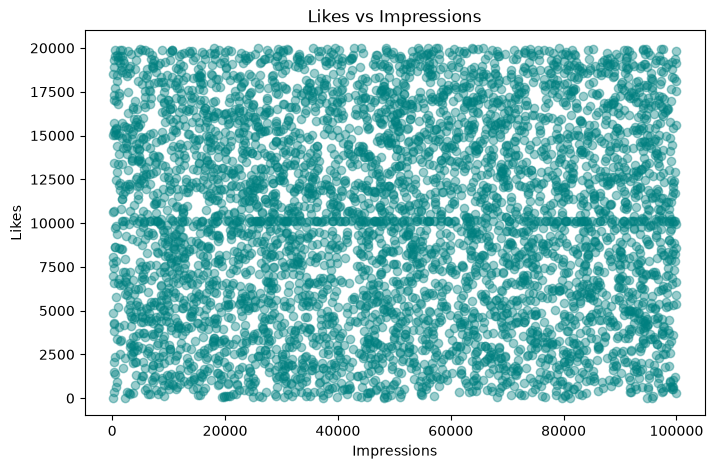

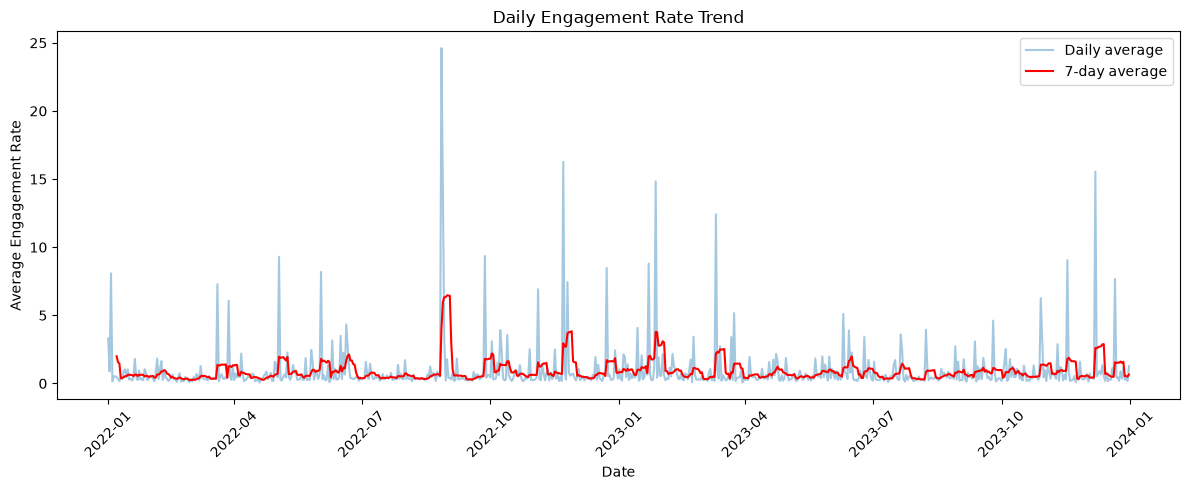

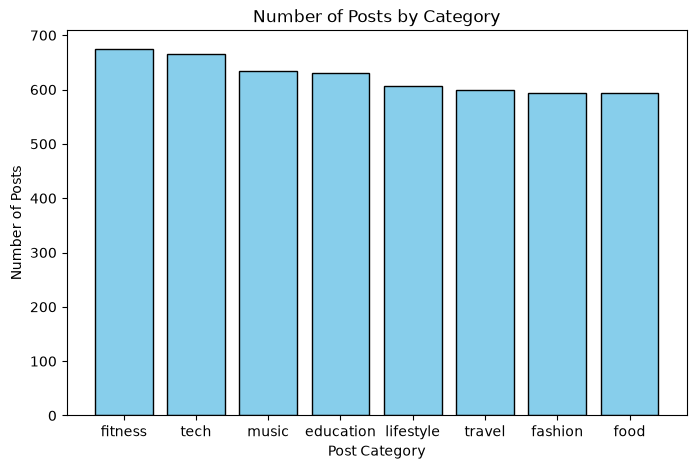

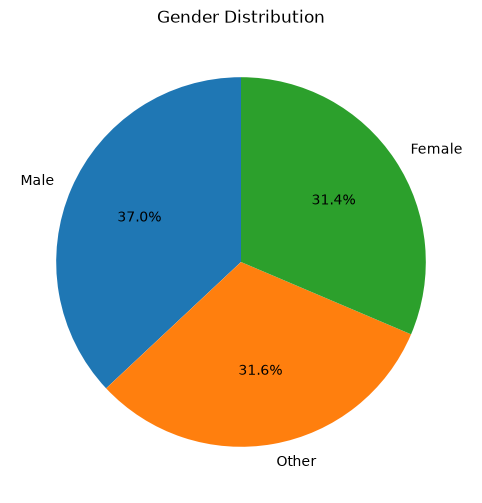

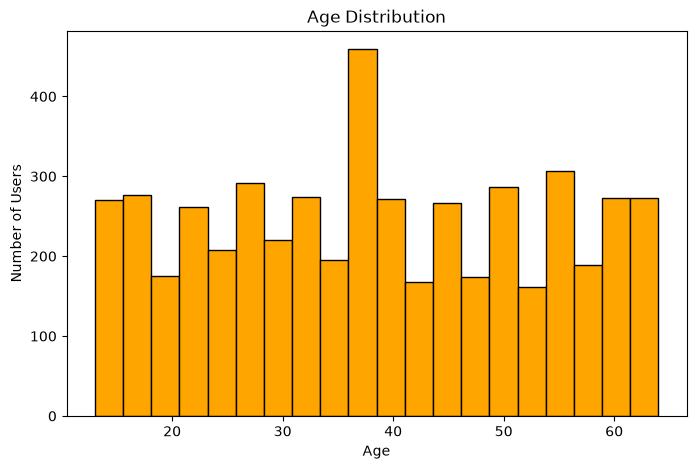

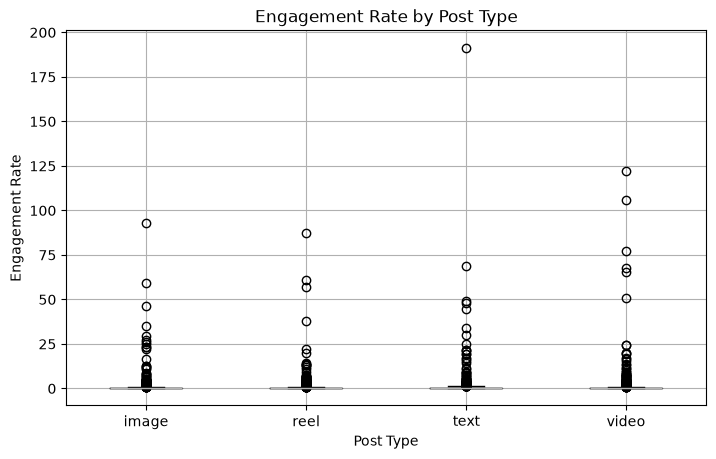

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Scatter: likes vs impressions
plt.figure(figsize=(8, 5))
plt.scatter(df['impression_count'], df['likes'], alpha=0.4, color='teal')
plt.title('Likes vs Impressions')
plt.xlabel('Impressions')
plt.ylabel('Likes')
plt.show()

# 2. Line: daily engagement trend
daily = df.groupby('posted_at')['engagement_rate'].mean()
plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily.values, alpha=0.4, label='Daily average')
plt.plot(daily.index, daily.rolling(7).mean(), color='red', label='7-day average')
plt.title('Daily Engagement Rate Trend')
plt.xlabel('Date')
plt.ylabel('Average Engagement Rate')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Bar: posts by category
category_counts = df['post_category'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')
plt.title('Number of Posts by Category')
plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.show()

# 4. Pie: gender distribution
gender_counts = df['gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.show()

# 5. Histogram: age
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, color='orange', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.show()

# 6. Box plot: engagement rate by post type
df.boxplot(column='engagement_rate', by='post_type', figsize=(8, 5))
plt.title('Engagement Rate by Post Type')
plt.suptitle('')
plt.xlabel('Post Type')
plt.ylabel('Engagement Rate')
plt.show()

In [81]:
#Part 2: Seaborn charts

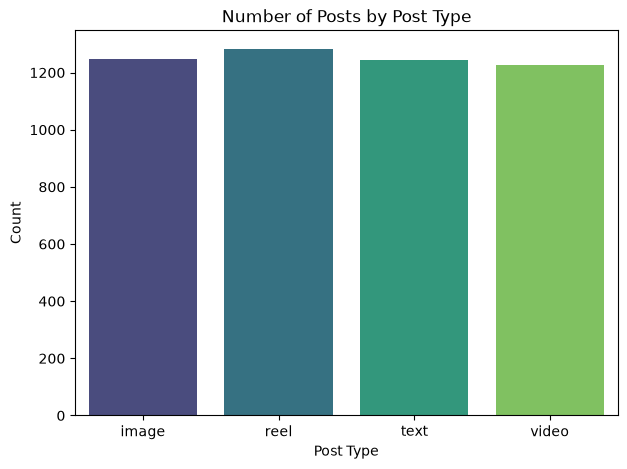

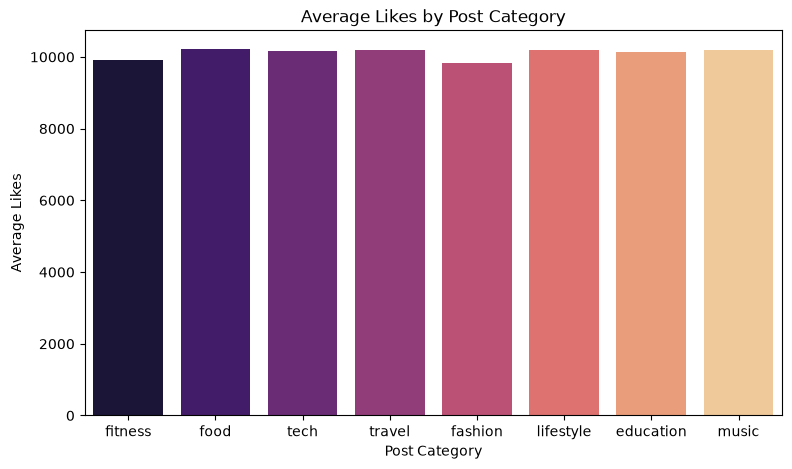

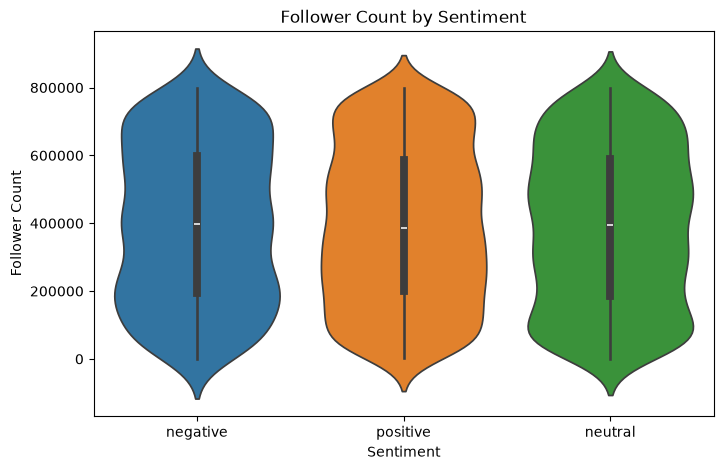

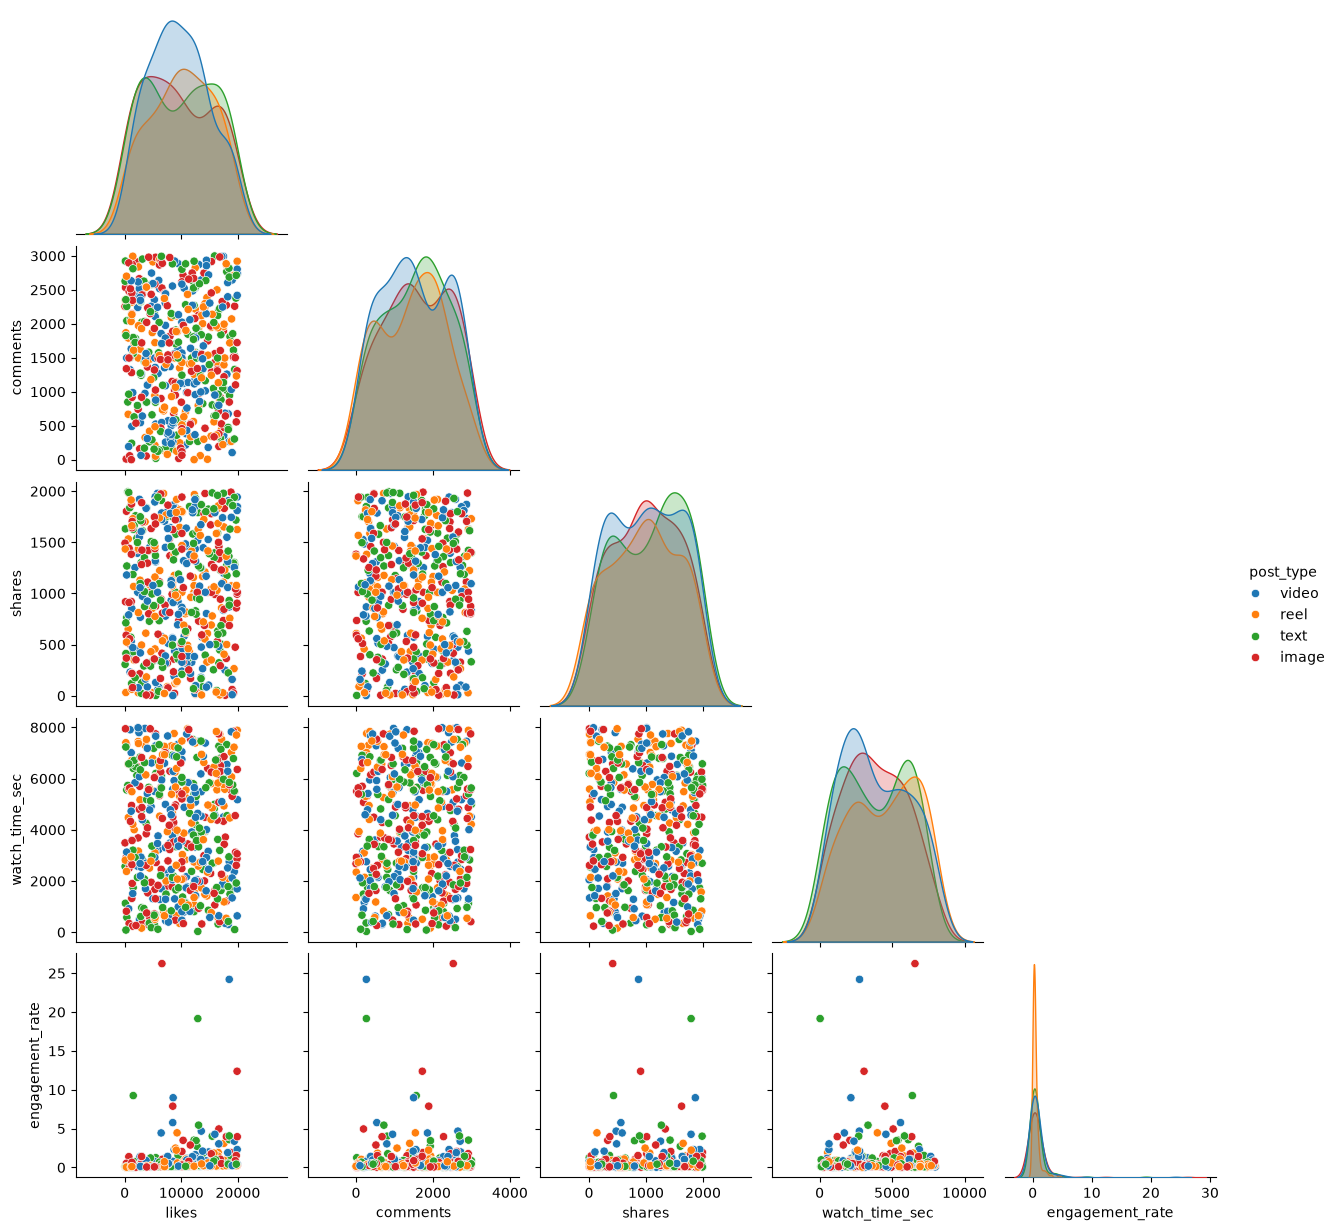

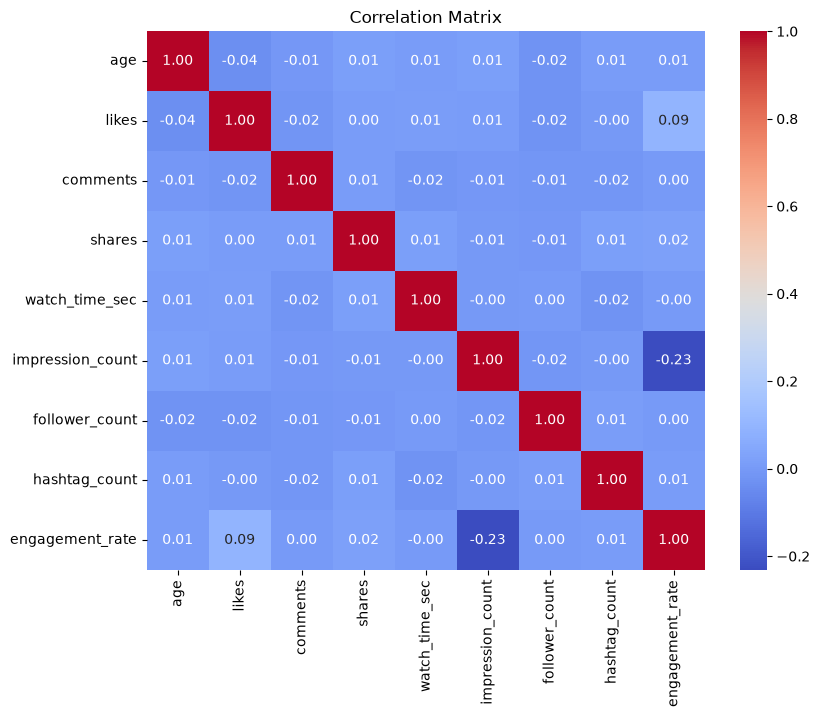

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 34.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 22.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 23.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 44.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, U

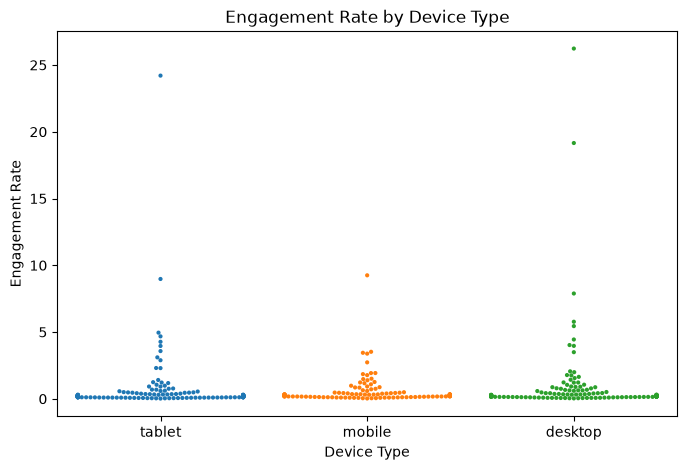

In [82]:
# 1. Count plot: post type
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='post_type', hue='post_type', palette='viridis', legend=False)
plt.title('Number of Posts by Post Type')
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.show()

# 2. Bar plot: average likes by category
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='post_category', y='likes', hue='post_category',
            palette='magma', legend=False, errorbar=None)
plt.title('Average Likes by Post Category')
plt.xlabel('Post Category')
plt.ylabel('Average Likes')
plt.show()

# 3. Violin plot: followers vs sentiment
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='sentiment', y='follower_count', hue='sentiment', legend=False)
plt.title('Follower Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.show()

# 4. Pair plot: numeric features (a sample of 500 rows keeps it fast)
pair_cols = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate']
sns.pairplot(df.sample(500, random_state=1)[pair_cols + ['post_type']],
             hue='post_type', corner=True)
plt.show()

# 5. Heatmap: correlation matrix
heat_cols = ['age', 'likes', 'comments', 'shares', 'watch_time_sec',
             'impression_count', 'follower_count', 'hashtag_count', 'engagement_rate']
plt.figure(figsize=(9, 7))
sns.heatmap(df[heat_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 6. Swarm plot: engagement vs device (a sample of 400 rows, since swarm plots are slow)
plt.figure(figsize=(8, 5))
sns.swarmplot(data=df.sample(400, random_state=1), x='device_type', y='engagement_rate',
              hue='device_type', legend=False, size=3)
plt.title('Engagement Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Engagement Rate')
plt.show()

In [83]:
#Part 3: Plotly (interactive charts)

In [84]:
import plotly.express as px

# 1. Interactive line chart: monthly average engagement rate
monthly = df.groupby(df['posted_at'].dt.to_period('M').astype(str))['engagement_rate'].mean().reset_index()
monthly.columns = ['month', 'avg_engagement_rate']
fig1 = px.line(monthly, x='month', y='avg_engagement_rate', markers=True,
               title='Monthly Average Engagement Rate')
fig1.show()

# 2. Interactive bar chart: average engagement score by post type
bar_data = df.groupby('post_type')['engagement_score'].mean().reset_index()
fig2 = px.bar(bar_data, x='post_type', y='engagement_score', color='post_type',
              title='Average Engagement Score by Post Type')
fig2.show()

# 3. Interactive scatter chart: likes vs impressions, colored by sentiment
fig3 = px.scatter(df.sample(1000, random_state=1), x='impression_count', y='likes',
                  color='sentiment', hover_data=['post_type', 'country'],
                  title='Likes vs Impressions (sample of 1000 posts)')
fig3.show()

# 4. Interactive bubble chart: country summary, bubble size = total posts
bubble = df.groupby('country').agg(
    avg_engagement_rate=('engagement_rate', 'mean'),
    avg_likes=('likes', 'mean'),
    posts=('post_id', 'count')
).reset_index()
fig4 = px.scatter(bubble, x='avg_likes', y='avg_engagement_rate', size='posts',
                  color='country', hover_name='country',
                  title='Countries: Average Likes vs Engagement Rate (bubble size = posts)')
fig4.show()

In [85]:
# ---------- CONTENT PERFORMANCE ----------
print("1. Post types ranked by average engagement rate:")
print(df.groupby('post_type')['engagement_rate'].mean().sort_values(ascending=False).round(4))
print("Highest:", df.groupby('post_type')['engagement_rate'].mean().idxmax())

print("\n2. Post categories ranked by average engagement rate:")
print(df.groupby('post_category')['engagement_rate'].mean().sort_values(ascending=False).round(4))
print("Best category:", df.groupby('post_category')['engagement_rate'].mean().idxmax())

print("\n3. Countries ranked by average engagement rate:")
print(df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False).round(4))

# ---------- USER TRENDS ----------
print("\n4. How age affects engagement:")
df['age_group'] = pd.cut(df['age'], bins=[0, 17, 24, 34, 44, 100],
                         labels=['Under 18', '18-24', '25-34', '35-44', '45+'])
print(df.groupby('age_group', observed=True)[['engagement_rate', 'likes', 'engagement_score']].mean().round(3))
print("Correlation of age with engagement rate:", round(df['age'].corr(df['engagement_rate']), 3))

print("\n5. Verified vs non-verified accounts:")
print(df.groupby('is_verified')[['engagement_rate', 'likes', 'impression_count', 'follower_count']].mean().round(3))

# ---------- BEHAVIORAL INSIGHTS ----------
print("\n6. Impressions by day of the week:")
df['weekday'] = df['posted_at'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
print(df.groupby('weekday')['impression_count'].mean().reindex(weekday_order).round(0))

print("\n   Impressions by month:")
print(df.groupby(df['posted_at'].dt.month_name())['impression_count'].mean().round(0).sort_values(ascending=False))

print("\n7. Device type and watch time:")
print(df.groupby('device_type')['watch_time_sec'].agg(['mean', 'median']).round(2))

# ---------- SENTIMENT ANALYSIS ----------
print("\n8. Performance by sentiment:")
print(df.groupby('sentiment')[['engagement_rate', 'likes', 'comments', 'shares', 'watch_time_sec']].mean().round(3))
print("Best sentiment:", df.groupby('sentiment')['engagement_rate'].mean().idxmax())

print("\n9. Negative and neutral posts by post type (count):")
print(df[df['sentiment'].isin(['negative', 'neutral'])].groupby(['sentiment', 'post_type']).size().unstack())

1. Post types ranked by average engagement rate:
post_type
video    1.1224
text     1.0645
image    0.8956
reel     0.7830
Name: engagement_rate, dtype: float64
Highest: video

2. Post categories ranked by average engagement rate:
post_category
food         1.3586
tech         1.1605
lifestyle    1.0910
music        0.8888
fitness      0.8656
education    0.8442
fashion      0.8071
travel       0.7022
Name: engagement_rate, dtype: float64
Best category: food

3. Countries ranked by average engagement rate:
country
Brazil       1.5407
Australia    1.3243
France       1.1464
UAE          1.1124
Canada       0.9167
UK           0.8510
Japan        0.7696
Germany      0.7590
India        0.6550
USA          0.5766
Name: engagement_rate, dtype: float64

4. How age affects engagement:
           engagement_rate      likes  engagement_score
age_group                                              
Under 18             0.862  10616.734         16586.127
18-24                1.036  10029.083     